In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
!pip install -q lightgbm

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%cd /content/drive/MyDrive/Data_Mining/Final_Project/data-mining-2026-final-project

/content/drive/MyDrive/Data_Mining/Final_Project/data-mining-2026-final-project


In [5]:
BASE = '/content/drive/MyDrive/Data_Mining/Final_Project/data-mining-2026-final-project'

# **Exploratory Data Analysis**

════════════════════════════════════════════════════════════
1. SHAPES & COLUMNS
════════════════════════════════════════════════════════════
train: (12319040, 21), test: (204568, 20), sub: (2248, 6)

feature cols: ['prec', 'surf_pre', 'humidity', 'tmp', 'dp_tmp', 'wb_tmp', 'tmp_max', 'tmp_min', 'tmp_range', 'surf_tmp', 'wind', 'wind_max', 'wind_min', 'wind_range']

════════════════════════════════════════════════════════════
2. REGIONS
════════════════════════════════════════════════════════════
train: 2248, test: 2248, sub: 2248
test == submission? True
test ⊆ train?       True

════════════════════════════════════════════════════════════
3. DAYS PER REGION
════════════════════════════════════════════════════════════
train: {'min': 5480.0, 'max': 5480.0, 'mean': 5480.0}
test : {'min': 91.0, 'max': 91.0, 'mean': 91.0}

════════════════════════════════════════════════════════════
4. DATE RANGES
════════════════════════════════════════════════════════════
train: 10004-12-31 → 8133-12-31

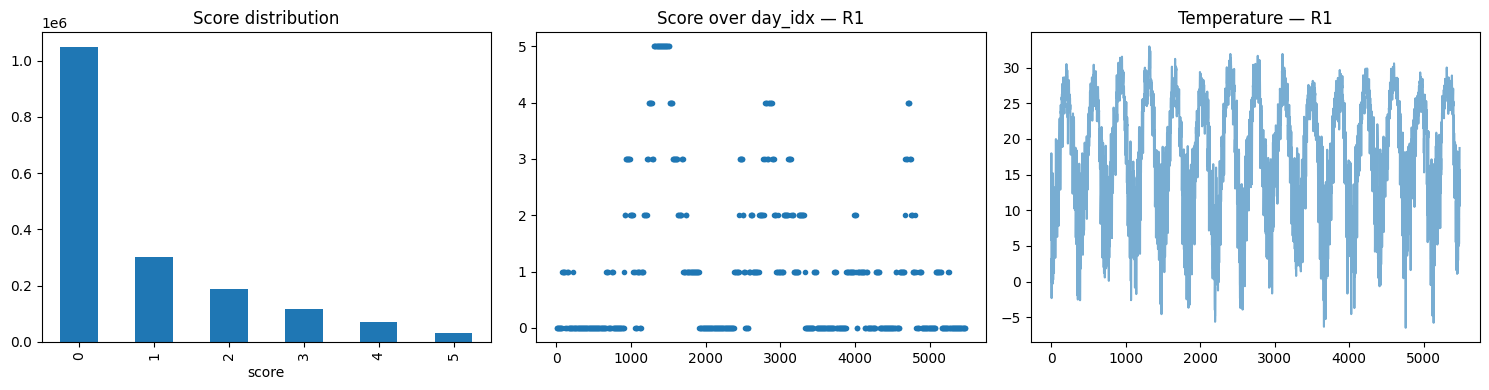

In [ ]:
train = pd.read_csv(f'{BASE}/data/train.csv')
test  = pd.read_csv(f'{BASE}/data/test.csv')
sub   = pd.read_csv(f'{BASE}/sample_submission.csv')

# String-based date features (robust to year 3000+ and fake leap days)
for df in (train, test):
    df['year']  = df['date'].str[:4].astype(int)
    df['month'] = df['date'].str[5:7].astype(int)
    df['day']   = df['date'].str[8:10].astype(int)

# Sort by region then date string (lexicographic == chronological for YYYY-MM-DD)
train = train.sort_values(['region_id', 'date']).reset_index(drop=True)
test  = test.sort_values(['region_id', 'date']).reset_index(drop=True)

# Per-region day index — this is what you'll actually use for windowing
train['day_idx'] = train.groupby('region_id').cumcount()
test['day_idx']  = test.groupby('region_id').cumcount()

# ───────────────────────── 1. Shapes & columns ─────────────────────────
print('═'*60); print('1. SHAPES & COLUMNS'); print('═'*60)
print(f'train: {train.shape}, test: {test.shape}, sub: {sub.shape}')
print(f'\nfeature cols: {[c for c in train.columns if c in test.columns and c not in ["region_id","date","year","month","day","day_idx"]]}')

# ───────────────────────── 2. Region coverage ─────────────────────────
print('\n' + '═'*60); print('2. REGIONS'); print('═'*60)
tr_regs, te_regs, sub_regs = set(train.region_id), set(test.region_id), set(sub.region_id)
print(f'train: {len(tr_regs)}, test: {len(te_regs)}, sub: {len(sub_regs)}')
print(f'test == submission? {te_regs == sub_regs}')
print(f'test ⊆ train?       {te_regs.issubset(tr_regs)}')

# ───────────────────────── 3. Days per region ─────────────────────────
print('\n' + '═'*60); print('3. DAYS PER REGION'); print('═'*60)
print('train:', train.groupby('region_id').size().describe()[['min','max','mean']].to_dict())
print('test :', test.groupby('region_id').size().describe()[['min','max','mean']].to_dict())

# ───────────────────────── 4. Date ranges & gap ─────────────────────────
print('\n' + '═'*60); print('4. DATE RANGES'); print('═'*60)
print(f'train: {train.date.min()} → {train.date.max()}')
print(f'test : {test.date.min()}  → {test.date.max()}')
sample_reg = sorted(te_regs)[0]
tr_last = train[train.region_id == sample_reg].date.max()
te_first = test[test.region_id == sample_reg].date.min()
print(f'\n{sample_reg}: train ends {tr_last}, test starts {te_first}')

# ───────────────────────── 5. Score distribution ─────────────────────────
print('\n' + '═'*60); print('5. SCORE'); print('═'*60)
print(f'NaN ratio    : {train.score.isna().mean():.4f}  (expect ≈ 0.857)')
print(f'non-NaN count: {train.score.notna().sum():,}')
print(f'unique values: {sorted(train.score.dropna().unique())}')
print('\nvalue counts:'); print(train.score.value_counts().sort_index())
print(f'\nmean score: {train.score.mean():.3f}')

# ───────────────────────── 6. Where do scores land in the week? ─────────
print('\n' + '═'*60); print('6. SCORE POSITION (day_idx mod 7)'); print('═'*60)
mod7 = train.loc[train.score.notna(), 'day_idx'] % 7
print(mod7.value_counts().sort_index())
print('(One value should dominate — that is your weekly anchor offset)')

# ───────────────────────── 7. Feature NaN ratios ─────────────────────────
print('\n' + '═'*60); print('7. NaN RATIOS'); print('═'*60)
feat_cols = [c for c in train.columns if c not in ['region_id','date','score','year','month','day','day_idx']]
nan_tr = train[feat_cols].isna().mean().sort_values(ascending=False)
nan_te = test[feat_cols].isna().mean().reindex(nan_tr.index)
print(pd.DataFrame({'train_NaN%': (nan_tr*100).round(2),
                    'test_NaN%' : (nan_te*100).round(2)}))

# ───────────────────────── 8. Quick visuals ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
train.score.dropna().astype(int).value_counts().sort_index().plot(
    kind='bar', ax=axes[0], title='Score distribution')
s = train[train.region_id == sample_reg]
axes[1].plot(s.day_idx, s.score, marker='.', linestyle='-')
axes[1].set_title(f'Score over day_idx — {sample_reg}')
axes[2].plot(s.day_idx, s.tmp, alpha=0.6)
axes[2].set_title(f'Temperature — {sample_reg}')
plt.tight_layout(); plt.show()

In [ ]:
import sys
from contextlib import redirect_stdout

OUT_PATH = f'{BASE}/eda_report.txt'  # saves to your Drive next to data/

class Tee:
    """Write to console AND file simultaneously."""
    def __init__(self, *streams): self.streams = streams
    def write(self, msg):
        for s in self.streams: s.write(msg)
    def flush(self):
        for s in self.streams: s.flush()

with open(OUT_PATH, 'w') as f, redirect_stdout(Tee(sys.__stdout__, f)):
    # ── paste the entire EDA block here (sections 1–7, skip the matplotlib part) ──

    print('═'*60); print('1. SHAPES & COLUMNS'); print('═'*60)
    print(f'train: {train.shape}, test: {test.shape}, sub: {sub.shape}')
    print(f'\nfeature cols: {[c for c in train.columns if c in test.columns and c not in ["region_id","date","year","month","day","day_idx"]]}')

    print('\n' + '═'*60); print('2. REGIONS'); print('═'*60)
    tr_regs, te_regs, sub_regs = set(train.region_id), set(test.region_id), set(sub.region_id)
    print(f'train: {len(tr_regs)}, test: {len(te_regs)}, sub: {len(sub_regs)}')
    print(f'test == submission? {te_regs == sub_regs}')
    print(f'test ⊆ train?       {te_regs.issubset(tr_regs)}')

    print('\n' + '═'*60); print('3. DAYS PER REGION'); print('═'*60)
    print('train:', train.groupby('region_id').size().describe()[['min','max','mean']].to_dict())
    print('test :', test.groupby('region_id').size().describe()[['min','max','mean']].to_dict())

    print('\n' + '═'*60); print('4. DATE RANGES'); print('═'*60)
    print(f'train: {train.date.min()} → {train.date.max()}')
    print(f'test : {test.date.min()}  → {test.date.max()}')
    sample_reg = sorted(te_regs)[0]
    tr_last = train[train.region_id == sample_reg].date.max()
    te_first = test[test.region_id == sample_reg].date.min()
    print(f'\n{sample_reg}: train ends {tr_last}, test starts {te_first}')

    print('\n' + '═'*60); print('5. SCORE'); print('═'*60)
    print(f'NaN ratio    : {train.score.isna().mean():.4f}  (expect ≈ 0.857)')
    print(f'non-NaN count: {train.score.notna().sum():,}')
    print(f'unique values: {sorted(train.score.dropna().unique())}')
    print('\nvalue counts:'); print(train.score.value_counts().sort_index())
    print(f'\nmean score: {train.score.mean():.3f}')

    print('\n' + '═'*60); print('6. SCORE POSITION (day_idx mod 7)'); print('═'*60)
    mod7 = train.loc[train.score.notna(), 'day_idx'] % 7
    print(mod7.value_counts().sort_index())

    print('\n' + '═'*60); print('7. NaN RATIOS'); print('═'*60)
    feat_cols = [c for c in train.columns if c not in ['region_id','date','score','year','month','day','day_idx']]
    nan_tr = train[feat_cols].isna().mean().sort_values(ascending=False)
    nan_te = test[feat_cols].isna().mean().reindex(nan_tr.index)
    print(pd.DataFrame({'train_NaN%': (nan_tr*100).round(2),
                        'test_NaN%' : (nan_te*100).round(2)}))

print(f'\n✅ Saved EDA report to {OUT_PATH}')


✅ Saved EDA report to /content/drive/MyDrive/Data_Mining/Final_Project/data-mining-2026-final-project/eda_report.txt


# **Baseline V1: Per-Region Monthly Mean**
Predicts each region's future weekly scores using its historical mean score for the matching calendar month — a seasonality-aware baseline with no model training required.

**Public LeaderBoard: 0.9506**

In [ ]:
!python {BASE}/baseline_v1_monthly_mean.py

[Loading]
  train: (12319040, 17), test: (204568, 16), sub: (2248, 6)

[Fitting lookups]
  region-month entries : 5,826
  unique regions       : 2,248
  global mean score    : 0.8357

[Local validation] Holding out the last 5 score-weeks per region...
  Local MAE on held-out 5-week tail: 0.8352

[Predicting]
  fallbacks (region mean): 0
  fallbacks (global mean): 0

[Saved] /content/drive/MyDrive/Data_Mining/Final_Project/data-mining-2026-final-project/baseline_v1_monthly_mean.csv

First 5 rows of submission:
  region_id  pred_week1  pred_week2  pred_week3  pred_week4  pred_week5
0        R1    1.107692    1.107692    1.044776    1.044776    1.044776
1        R2    0.687500    0.687500    0.687500    0.687500    0.818182
2        R3    1.417910    1.250000    1.250000    1.250000    1.250000
3        R4    1.181818    1.181818    1.181818    1.230769    1.230769
4        R6    1.476923    1.476923    1.323077    1.323077    1.323077

Prediction stats:
       pred_week1  pred_week2  pre

# **Baseline V1.5: Per-Region Monthly Median**
Predicts each region's future weekly scores using its historical median score for the matching calendar month — a seasonality-aware baseline with no model training required.

**Public LeaderBoard: 1.0271**

In [ ]:
!python {BASE}/baseline_v1_5_monthly_median.py

[Loading]
  train: (12319040, 17), test: (204568, 16), sub: (2248, 6)

[Fitting lookups (median)]
  region-month entries  : 5,826
  unique regions        : 2,248
  global median score   : 0.0000
  fraction of (region,month) medians == 0: 0.623

[Local validation] Holding out last 5 score-weeks per region...
  Local MAE on held-out 5-week tail: 0.4461

[Predicting]
  fallbacks (region median): 0
  fallbacks (global median): 0

[Saved] /content/drive/MyDrive/Data_Mining/Final_Project/data-mining-2026-final-project/baseline_v1_5_monthly_median.csv

First 5 rows:
  region_id  pred_week1  pred_week2  pred_week3  pred_week4  pred_week5
0        R1         0.0         0.0         1.0         1.0         1.0
1        R2         0.0         0.0         0.0         0.0         0.0
2        R3         1.0         0.0         0.0         0.0         0.0
3        R4         1.0         1.0         1.0         1.0         1.0
4        R6         1.0         1.0         0.0         0.0         0.0

P

# **LightGBM**

## **Baseline V2: Minimal LightGBM with 91-Day Weather Aggregates**
A LightGBM regressor trained on basic weather aggregates (mean/min/max/std of 14 meteorological features over each 91-day window) with five separate models for each week-ahead horizon, optimizing MAE directly.

**Public LeaderBoard: 0.9435**

In [ ]:
!python {BASE}/baseline_v2_lgbm_minimal.py

[Loading]
  train: (12319040, 17), test: (204568, 16), sub: (2248, 6)
  unique regions: 2248

[Building training windows]
  Processing 2248 regions...
    500/2248 regions (8s)
    1000/2248 regions (13s)
    1500/2248 regions (18s)
    2000/2248 regions (24s)
  Built X: (343944, 58), y: (343944, 5)
  NaN in targets: 0  (should be 0)

[Train/val split]
  train: (310224, 58), val: (33720, 58)

[Training 5 LightGBM models]

  ── Week 1 ──
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:743: UserWarning: Usage of np.ndarray subset (sliced data) is not recommended due to it will double the peak memory cost in LightGBM.
  _log_warning(
Training until validation scores don't improve for 40 rounds
Early stopping, best iteration is:
[36]	val's l1: 0.50027
  Week 1 val MAE: 0.5003

  ── Week 2 ──
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
Training until validation scores don't improve for 40 rounds
Early stopping, best iteration is:
[32]	va

## **Baseline V3: LightGBM with Engineered Features and Time-Aware Validation**
A LightGBM regressor with 90 engineered features (recency aggregates, drought indicators, and trend slopes) trained under a buffered time-based validation scheme that eliminates the input-overlap leak present in V2.

**Public LeaderBoard: 0.9168**

In [ ]:
!python {BASE}/baseline_v3_lgbm_features.py

[Loading]
  train: (12319040, 17), test: (204568, 16), sub: (2248, 6)

[Building training windows]
  Processing 2248 regions...
    500/2248 regions (31s)
    1000/2248 regions (60s)
    1500/2248 regions (90s)
    2000/2248 regions (119s)
  Built X: (343944, 90), y: (343944, 5)
  NaN in targets: 0 (should be 0)

[Train/val split with buffer]
  train: 325,960, val: 11,240, buffer dropped: 6,744
  feature count: 90

[Training 5 LightGBM models]

  ── Week 1 ──
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:743: UserWarning: Usage of np.ndarray subset (sliced data) is not recommended due to it will double the peak memory cost in LightGBM.
  _log_warning(
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[40]	val's l1: 0.46396
  Week 1 val MAE: 0.4640

  ── Week 2 ──
[LightGBM] [Warning] Met negative value in categorical features, will convert it

Compares V3's prediction distribution against the training distribution to diagnose whether predictions are miscalibrated (e.g., systematically overshooting or undershooting the dominant zero class).

In [ ]:
sub = pd.read_csv(f'{BASE}/baseline_v3_lgbm_features/baseline_v3_lgbm_features.csv')
preds = sub[['pred_week1','pred_week2','pred_week3','pred_week4','pred_week5']]

# 1. Summary stats per week
print('═' * 60)
print('SUMMARY STATS PER WEEK')
print('═' * 60)
print(preds.describe().round(4))

# 2. Overall distribution
all_preds = preds.values.flatten()
print('\n' + '═' * 60)
print('OVERALL PREDICTION DISTRIBUTION')
print('═' * 60)
print(f'Total predictions : {len(all_preds):,}')
print(f'Mean              : {all_preds.mean():.4f}')
print(f'Median            : {np.median(all_preds):.4f}')
print(f'Std               : {all_preds.std():.4f}')
print(f'Min / Max         : {all_preds.min():.4f} / {all_preds.max():.4f}')

# 3. Threshold buckets — what fraction would round to 0?
print('\n' + '═' * 60)
print('FRACTION OF PREDICTIONS BELOW THRESHOLD')
print('═' * 60)
for t in [0.1, 0.2, 0.3, 0.5, 1.0, 1.5, 2.0, 3.0]:
    frac = (all_preds < t).mean()
    print(f'  < {t:.1f} : {frac:.4f}  ({int(frac * len(all_preds)):,} / {len(all_preds):,})')

# 4. Compare to training score distribution
print('\n' + '═' * 60)
print('TRAINING SCORE DISTRIBUTION (for reference)')
print('═' * 60)
train = pd.read_csv(f'{BASE}/data/train.csv')
scores = train['score'].dropna().astype(int)
print(f'Mean   : {scores.mean():.4f}')
print(f'Median : {scores.median():.4f}')
print(f'Std    : {scores.std():.4f}')
print(f'\nValue counts:')
print(scores.value_counts().sort_index())
print(f'\nFraction == 0: {(scores == 0).mean():.4f}')

# 5. Histogram-style print
print('\n' + '═' * 60)
print('HISTOGRAM OF PREDICTIONS (binned)')
print('═' * 60)
bins = [0, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0, 1.5, 2.0, 3.0, 5.0]
counts, _ = np.histogram(all_preds, bins=bins)
for i, c in enumerate(counts):
    pct = 100 * c / len(all_preds)
    bar = '█' * int(pct / 2)
    print(f'  [{bins[i]:.1f}, {bins[i+1]:.1f}): {c:>6,} ({pct:5.2f}%) {bar}')

════════════════════════════════════════════════════════════
SUMMARY STATS PER WEEK
════════════════════════════════════════════════════════════
       pred_week1  pred_week2  pred_week3  pred_week4  pred_week5
count   2248.0000   2248.0000   2248.0000   2248.0000   2248.0000
mean       0.9996      0.9927      0.8978      0.8235      0.8027
std        0.7942      0.8264      0.7424      0.7073      0.7161
min        0.0000      0.0000      0.0000      0.0000      0.0000
25%        0.2963      0.2704      0.2503      0.2140      0.1840
50%        0.9165      0.8284      0.7817      0.6786      0.6097
75%        1.5080      1.5042      1.3289      1.2584      1.2575
max        3.5199      3.6641      3.4265      2.9839      3.0812

════════════════════════════════════════════════════════════
OVERALL PREDICTION DISTRIBUTION
════════════════════════════════════════════════════════════
Total predictions : 11,240
Mean              : 0.9033
Median            : 0.7586
Std               : 0.762

A post-hoc calibration step that applies quantile mapping to V3's predictions, rescaling each prediction to the training-score value at the same percentile rank to align the prediction distribution with the training distribution.

**Public LeaderBoard: 0.9673**

In [ ]:
!python {BASE}/calibrate_v3.py

[Loading]
  V3 submission: (2248, 6)
  training scores: 1,757,936

[Quantile mapping]

  Raw V3 predictions:
    mean   : 0.9033
    median : 0.7586
    std    : 0.7629
    < 0.1  : 0.1558
    < 0.5  : 0.3879
    > 2.0  : 0.1093

  Fully calibrated (blend=1.0):
    mean   : 0.8359
    median : 0.0000
    std    : 1.2618
    < 0.1  : 0.5963
    < 0.5  : 0.5963
    > 2.0  : 0.1251

  Training scores (target):
    mean   : 0.8357
    median : 0.0000
    std    : 1.2615
    < 0.1  : 0.5963
    < 0.5  : 0.5963
    > 2.0  : 0.1251

[Blending] blend factor = 0.5

  Blended (blend=0.5):
    mean   : 0.8696
    median : 0.3793
    std    : 0.9963
    < 0.1  : 0.2266
    < 0.5  : 0.5963
    > 2.0  : 0.1251

[Saved] /content/drive/MyDrive/Data_Mining/Final_Project/data-mining-2026-final-project/baseline_v3_calibrated.csv

[Saving variants for comparison]
  blend=0.25 → mean=0.886, median=0.569, <0.5=0.461  →  /content/drive/MyDrive/Data_Mining/Final_Project/data-mining-2026-final-project/baseline

## **Baseline V5: LightGBM with Score History from Training Data**
A LightGBM regressor combining V3's weather features with climatology anomalies and per-region historical score statistics for 105 total features.

**Public LeaderBoard: 0.9017**

In [ ]:
!python {BASE}/baseline_v5_lgbm_score_history.py

[Loading]
  train: (12319040, 17), test: (204568, 16), sub: (2248, 6)

[Climatology — weather]
  Building climatology lookup tables (weather)...
  weather climatology shape: (5826, 6)

[Climatology — scores (from train only, leakage-free)]
  Building score-history lookup tables...
  region_score_mean : 2,248 entries
  region_month_mean : 5,826 entries
  region_lastyr_mean: 2,248 entries
  global score mean : 0.8357

[Building training windows]
  Processing 2248 regions...
    500/2248 regions (60s)
    1000/2248 regions (122s)
    1500/2248 regions (180s)
    2000/2248 regions (239s)
  Built X: (343944, 105), y: (343944, 5)
  NaN in targets: 0 (should be 0)

[Train/val split with buffer]
  train: 325,960, val: 11,240, buffer dropped: 6,744
  feature count: 105

[Training 5 LightGBM models]

  ── Week 1 ──
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:743: UserWarning: Usage of np.ndarray subset (sliced data) is not recommended due to it will double the peak memory cost in L

## **Baseline V6: LightGBM with Recent-Drought and Region-Month Detail Features**
Extends V5 with twelve additional drought-baseline features — including recent-year score statistics, richer per-region-month distributional summaries, and recent-vs-historical contrasts — totaling 117 features computed exclusively from training data.

**Public LeaderBoard: **

In [ ]:
!python {BASE}/baseline_v6_lgbm_recent_drought.py

[Loading]
  train: (12319040, 17), test: (204568, 16), sub: (2248, 6)

[Building lookup tables]
  Weather climatology...
  Recent score-history (last 52 weeks)...
/content/drive/MyDrive/Data_Mining/Final_Project/data-mining-2026-final-project/baseline_v6_lgbm_recent_drought.py:165: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  'recent_score_trend': grouped.apply(slope_per_group),
  Region-month detail (max/std/p75/frequencies)...
  recent_df shape: (2248, 5), regmon_df shape: (5826, 5)

[Building training windows]
  Processing 2248 regions...
    500/2248 regions (77s)
    1000/2248 regions (153s)
    1500/2248 regions (243s)
    2000/2248 regions (321s)
  Built X: (343944, 117), y: (343944, 5)



### **Ensemble V3, V5, and V6**
**Public LeaderBoard: 0.9035**

In [ ]:
!python {BASE}/ensemble_v3v5v6.py

[Loading submissions]
  All three have 2,248 rows in matching order ✓

[Original prediction distributions]
  V3                             mean=0.9033  median=0.7586  std=0.7629  <0.5=0.388  >2.0=0.109
  V5                             mean=0.9310  median=0.7814  std=0.7946  <0.5=0.384  >2.0=0.120
  V6                             mean=0.9556  median=0.7885  std=0.8329  <0.5=0.385  >2.0=0.131

[Ensemble variant distributions]
  mean V3+V5+V6                  mean=0.9300  median=0.7759  std=0.7796  <0.5=0.376  >2.0=0.116
  mean V5+V6                     mean=0.9433  median=0.7836  std=0.8085  <0.5=0.384  >2.0=0.124
  weighted (V5 heavy)            mean=0.9329  median=0.7831  std=0.7861  <0.5=0.378  >2.0=0.119
  median V3+V5+V6                mean=0.9310  median=0.7849  std=0.7871  <0.5=0.379  >2.0=0.119

[Pairwise correlations of model predictions, week-1]
  V3 vs V5: 0.9240
  V3 vs V6: 0.9146
  V5 vs V6: 0.9776
  (lower correlation → more diverse → ensembling helps more)

[Saving varian

# **Neural Network**

## **Baseline V7: Temporal Convolutional Network (TCN)**
A residual 1D-CNN with five dilated convolution blocks (receptive field 125 days) that processes the full 91-day weather sequence as a multivariate signal, augmented with a learned region embedding, trained jointly to predict all five weekly horizons.

**Public LeaderBoard: 0.8463**

In [ ]:
!python {BASE}/baseline_v7_tcn.py

[Device] cuda
[Loading raw data]
  train: (12319040, 17), test: (204568, 16)
[Region encoding]
[Normalization stats]
  Computing per-region normalization stats...
[Building training windows]
  Building train windows across 2248 regions...
  X: (343944, 91, 14), y: (343944, 5)
[Train/val split with buffer]
  train: 325,960, val: 11,240, buffer dropped: 6,744
[Building test windows]
  Building test windows across 2248 regions...

[Model]
  TCN: 5 blocks × 64 channels, 148,741 params

[Training] 60 epochs max, patience 8
  ep   1/60  tr 0.5776  val 0.4459  [w1 0.457 w2 0.455 w3 0.444 w4 0.422 w5 0.452]  24s  ★
  ep   2/60  tr 0.4660  val 0.4336  [w1 0.434 w2 0.432 w3 0.430 w4 0.422 w5 0.450]  21s  ★
  ep   3/60  tr 0.4132  val 0.4322  [w1 0.433 w2 0.434 w3 0.430 w4 0.419 w5 0.445]  21s  ★
  ep   4/60  tr 0.3813  val 0.4617  [w1 0.465 w2 0.471 w3 0.464 w4 0.445 w5 0.463]  22s   
  ep   5/60  tr 0.3618  val 0.4337  [w1 0.436 w2 0.443 w3 0.437 w4 0.418 w5 0.436]  22s   
  ep   6/60  tr 0.343

Quick retrain with more regularization (over-regularize NN models, hurt convrgence)

In [ ]:
!python {BASE}/baseline_v7_1_tcn_reg.py

[Device] cuda
[Regularization config]
  dropout=0.3, lr=0.0003, wd=0.001, channels=48, patience=12
[Loading raw data]
  train: (12319040, 17), test: (204568, 16)
[Region encoding]
[Normalization stats]
  Computing per-region normalization stats...
[Building training windows]
  Building train windows across 2248 regions...
  X: (343944, 91, 14), y: (343944, 5)
[Train/val split with buffer]
  train: 325,960, val: 11,240, buffer dropped: 6,744
[Building test windows]
  Building test windows across 2248 regions...

[Model]
  TCN: 5 blocks × 48 channels, 92,245 params

[Training] 60 epochs max, patience 12
  ep   1/60  tr 0.6581  val 0.4786  [w1 0.483 w2 0.492 w3 0.481 w4 0.459 w5 0.478]  34s  ★
  ep   2/60  tr 0.5797  val 0.5044  [w1 0.504 w2 0.508 w3 0.497 w4 0.492 w5 0.520]  35s   
  ep   3/60  tr 0.5524  val 0.4700  [w1 0.472 w2 0.476 w3 0.465 w4 0.453 w5 0.484]  37s  ★
  ep   4/60  tr 0.5341  val 0.4751  [w1 0.475 w2 0.478 w3 0.468 w4 0.462 w5 0.492]  38s   
  ep   5/60  tr 0.5179  val

### **Ensemble V5 + V7**
**Public LeaderBoard: 0.8353**

In [ ]:
!python {BASE}/ensemble_v5_v7.py

[Loading submissions]
  Both have 2,248 rows in matching order ✓

[Original prediction distributions]
  V5 (LightGBM, LB 0.9017)       mean=0.9310  median=0.7814  std=0.7946  <0.5=0.384  >2.0=0.120
  V7 (TCN,      LB 0.8463)       mean=1.0971  median=0.7141  std=1.1649  <0.5=0.437  >2.0=0.222

[Pairwise correlation by week]
  week 1: 0.7357
  week 2: 0.7284
  week 3: 0.7351
  week 4: 0.7367
  week 5: 0.7471

[Ensemble variant distributions]
  ensemble_v5v7_mean             mean=1.0141  median=0.7876  std=0.9149  <0.5=0.384  >2.0=0.159
  ensemble_v5v7_v7heavy          mean=1.0307  median=0.7692  std=0.9571  <0.5=0.396  >2.0=0.172
  ensemble_v5v7_v5heavy          mean=0.9975  median=0.8071  std=0.8780  <0.5=0.377  >2.0=0.149
  ensemble_v5v7_v7stronger       mean=1.0473  median=0.7563  std=1.0037  <0.5=0.407  >2.0=0.184

[Saving variants]
  ensemble_v5v7_mean.csv saved
  ensemble_v5v7_v7heavy.csv saved
  ensemble_v5v7_v5heavy.csv saved
  ensemble_v5v7_v7stronger.csv saved

[Recommendation

## **Baseline V7: Temporal Convolutional Network (TCN) - 5 seeds (42 - 46)**
**Public LeaderBoard: 0.8071**

In [ ]:
!python baseline_v7_tcn_5seed_avg.py \
    --base {BASE} \
    --out baseline_v7_tcn_5seed_avg.csv \
    --epochs 60

[Device] cuda
[Seeds] [42, 43, 44, 45, 46]
[Loading raw data]
  train: (12319040, 17), test: (204568, 16)
[Region encoding]
[Normalization stats]
  Computing per-region normalization stats...
[Building training windows]
  Building train windows across 2248 regions...
  X: (343944, 91, 14), y: (343944, 5)
[Train/val split with buffer]
  train: 325,960, val: 11,240, buffer dropped: 6,744
[Building test windows]
  Building test windows across 2248 regions...

[Seed 42] Training fresh TCN
  TCN: 5 blocks × 64 channels, 148,741 params

[Seed 42] Training: 60 epochs max, patience 8
  seed 42 | ep   1/60  tr 0.5780  val 0.4580  [w1 0.466 w2 0.467 w3 0.456 w4 0.434 w5 0.467]  21s  ★
  seed 42 | ep   2/60  tr 0.4671  val 0.4343  [w1 0.438 w2 0.435 w3 0.431 w4 0.421 w5 0.447]  20s  ★
  seed 42 | ep   3/60  tr 0.4089  val 0.4589  [w1 0.464 w2 0.463 w3 0.457 w4 0.442 w5 0.469]  20s   
  seed 42 | ep   4/60  tr 0.3781  val 0.4498  [w1 0.447 w2 0.452 w3 0.450 w4 0.437 w5 0.463]  20s   
  seed 42 | e

### **Ensemble V5 + V7 - 5 seeds**

In [ ]:
!python {BASE}/ensemble_v5_v7_5seed.py \
    --v7-5seed baseline_v7_tcn_5seed_avg.csv

[Loading submissions]
  Both have 2,248 rows in matching order ✓

[Original prediction distributions]
  V5 (LB 0.9017)                      mean=0.9310  median=0.7814  std=0.7946  <0.5=0.384  >2.0=0.120
  V7-5seed (LB 0.8071)                mean=1.0323  median=0.6878  std=1.0259  <0.5=0.436  >2.0=0.193

[Pairwise correlation by week]
  week 1: 0.7771
  week 2: 0.7690
  week 3: 0.7733
  week 4: 0.7802
  week 5: 0.7802

[Ensemble variant distributions]
  ensemble_v5_v7_5seed_mean           mean=0.9817  median=0.7851  std=0.8581  <0.5=0.380  >2.0=0.146
  ensemble_v5_v7_5seed_v7heavy        mean=0.9918  median=0.7663  std=0.8847  <0.5=0.390  >2.0=0.155
  ensemble_v5_v7_5seed_v7stronger     mean=1.0019  median=0.7425  std=0.9151  <0.5=0.402  >2.0=0.163

[Saving variants]
  ensemble_v5_v7_5seed_mean.csv saved
  ensemble_v5_v7_5seed_v7heavy.csv saved
  ensemble_v5_v7_5seed_v7stronger.csv saved

[Recommendation]
  V7-5seed (LB 0.81) is much stronger than V5 (LB 0.90), so
  weighting V7 more he

## **Baseline V8: P-sLSTM with Patching and Channel Independence**
A sequence model based on Kong et al. (2025) that processes each of the 14 weather channels independently as 11 overlapping 16-day patches through a 2-layer sLSTM with exponential gating, combined with a learned region embedding to predict all five weekly horizons.

*Channel independence works when channels are independent. Our 14 channels are highly correlated.*

In [ ]:
# Single Head
!python {BASE}/baseline_v8_pslstm.py

[Device] cuda
[Loading raw data]
  train: (12319040, 17), test: (204568, 16)
[Region encoding]
[Normalization stats]
  Computing per-region normalization stats...
[Building training windows]
  Building train windows across 2248 regions...
  X: (343944, 91, 14), y: (343944, 5)
[Train/val split with buffer]
  train: 325,960, val: 11,240, buffer dropped: 6,744
[Building test windows]
  Building test windows across 2248 regions...

[Model]
  P-sLSTM: d_model=64, n_layers=2, patch=16/8, n_patches=11, 88,946 params

[Training] 80 epochs max, patience 10
  ep   1/80  tr 0.7112  val 0.7419  [w1 0.745 w2 0.753 w3 0.745 w4 0.734 w5 0.733]  57s  ★
  ep   2/80  tr 0.5386  val 0.7128  [w1 0.720 w2 0.722 w3 0.716 w4 0.700 w5 0.707]  53s  ★
  ep   3/80  tr 0.4901  val 0.7372  [w1 0.738 w2 0.747 w3 0.740 w4 0.726 w5 0.734]  53s   
  ep   4/80  tr 0.4642  val 0.7372  [w1 0.735 w2 0.749 w3 0.737 w4 0.728 w5 0.738]  51s   
  ep   5/80  tr 0.4455  val 0.7143  [w1 0.713 w2 0.721 w3 0.716 w4 0.711 w5 0.710]

In [ ]:
# Multi-Head
!python {BASE}/baseline_v8_1_pslstm_mh.py

[Device] cuda
[Regularization config]
  dropout=0.25, lr=0.0005, wd=0.0005, n_heads=4, d_model=64
[Loading raw data]
  train: (12319040, 17), test: (204568, 16)
[Region encoding]
[Normalization stats]
  Computing per-region normalization stats...
[Building training windows]
  Building train windows across 2248 regions...
  X: (343944, 91, 14), y: (343944, 5)
[Train/val split with buffer]
  train: 325,960, val: 11,240, buffer dropped: 6,744
[Building test windows]
  Building test windows across 2248 regions...

[Model]
  P-sLSTM-MH: d_model=64 (4 heads × 16), n_layers=2, n_patches=11, 64,370 params

[Training] 80 epochs max, patience 12
  ep   1/80  tr 0.8300  val 0.6918  [w1 0.714 w2 0.714 w3 0.692 w4 0.669 w5 0.670]  59s  ★
  ep   2/80  tr 0.6815  val 0.7258  [w1 0.738 w2 0.743 w3 0.721 w4 0.710 w5 0.718]  58s   
  ep   3/80  tr 0.6395  val 0.7670  [w1 0.750 w2 0.775 w3 0.773 w4 0.769 w5 0.769]  59s   
  ep   4/80  tr 0.6153  val 0.7286  [w1 0.724 w2 0.735 w3 0.726 w4 0.725 w5 0.733] 

In [ ]:
# Multi-Head, 5 seeds
!python {BASE}/baseline_v8_1_pslstm_mh_5seed_avg.py

[Device] cuda
[Seeds] [42, 43, 44, 45, 46]
[Regularization config]
  dropout=0.25, lr=0.0005, wd=0.0005, n_heads=4, d_model=64
[Loading raw data]
  train: (12319040, 17), test: (204568, 16)
[Region encoding]
[Normalization stats]
  Computing per-region normalization stats...
[Building training windows]
  Building train windows across 2248 regions...
  X: (343944, 91, 14), y: (343944, 5)
[Train/val split with buffer]
  train: 325,960, val: 11,240, buffer dropped: 6,744
[Building test windows]
  Building test windows across 2248 regions...

[Seed 42] Training fresh V8.1 multi-head P-sLSTM
  P-sLSTM-MH: d_model=64 (4 heads × 16), n_layers=2, n_patches=11, 64,370 params

[Seed 42] Training: 80 epochs max, patience 12
  seed 42 | ep   1/80  tr 0.8300  val 0.6918  [w1 0.714 w2 0.714 w3 0.692 w4 0.669 w5 0.670]  59s  ★
  seed 42 | ep   2/80  tr 0.6815  val 0.7258  [w1 0.738 w2 0.743 w3 0.721 w4 0.710 w5 0.718]  62s   
  seed 42 | ep   3/80  tr 0.6395  val 0.7670  [w1 0.750 w2 0.775 w3 0.773 w

### **Ensemble 4-way V5 + V7 - 10 seeds + V10 - 5 seeds + V8 - 5 seeds**

In [ ]:
!python {BASE}/ensemble_4way_with_v8.py

BASE = /content/drive/MyDrive/Data_Mining/Final_Project/data-mining-2026-final-project

Loaded:
  V5:          baseline_v5_lgbm_score_history.csv    (2248 rows)
  V7-10seed:   baseline_v7_tcn_10seed_avg.csv    (2248 rows)
  V10-5seed:   baseline_v10_tcn_static_5seed_avg.csv   (2248 rows)
  V8.1-5seed:  baseline_v8_1_pslstm_mh_5seed_avg.csv  (2248 rows)

Per-week mean check (bias diagnostic — V8.1 expected ~0.20 below V7/V10):
  week           V5    V7-10    V10-5   V8.1-5
  pred_week1   1.0309   1.1215   1.1372   0.7594
  pred_week2   0.9815   1.1287   1.1469   0.7587
  pred_week3   0.9043   1.1172   1.1336   0.7615
  pred_week4   0.8804   1.0957   1.1036   0.7620
  pred_week5   0.8581   1.0793   1.0868   0.7524

V8.1 vs V7-10 mean bias: 0.3497
  ⚠ Bias > 0.30 — V8.1 may drag the ensemble more than expected. Consider rerunning with W_V8_1 = 0.03 instead of 0.05.

Weights: V5 0.15, V7-10seed 0.5, V10-5seed 0.3, V8.1-5seed 0.05

Blend per-week means (compare to current best 0.7948 ensemb

## **Baseline V7-large: TCN with Increased Capacity**
A deeper, wider Temporal Convolutional Network (6 dilated blocks × 96 channels, 254-day receptive field) with proportionally increased dropout and weight decay, designed to extract more signal from the 91-day weather sequence than V7's smaller 5-block × 64-channel configuration could.

**Public LeaderBoard: don't submit**

In [ ]:
!python {BASE}/baseline_v7_large_tcn.py

[Device] cuda
[V7-large config]
  channels=96, n_blocks=6, dropout=0.15, lr=0.0007, wd=0.0003
[Loading raw data]
  train: (12319040, 17), test: (204568, 16)
[Region encoding]
[Normalization stats]
  Computing per-region normalization stats...
[Building training windows]
  Building train windows across 2248 regions...
  X: (343944, 91, 14), y: (343944, 5)
[Train/val split with buffer]
  train: 325,960, val: 11,240, buffer dropped: 6,744
[Building test windows]
  Building test windows across 2248 regions...

[Model]
  TCN-large: 6 blocks × 96 channels, 365,221 params

[Training] 80 epochs max, patience 10
  ep   1/80  tr 0.5852  val 0.5270  [w1 0.509 w2 0.521 w3 0.522 w4 0.525 w5 0.557]  46s  ★
  ep   2/80  tr 0.4718  val 0.4809  [w1 0.479 w2 0.483 w3 0.478 w4 0.466 w5 0.498]  47s  ★
  ep   3/80  tr 0.4139  val 0.4664  [w1 0.452 w2 0.459 w3 0.465 w4 0.466 w5 0.491]  48s  ★
  ep   4/80  tr 0.3760  val 0.5301  [w1 0.502 w2 0.515 w3 0.524 w4 0.540 w5 0.570]  48s   
  ep   5/80  tr 0.3565  v

## **Baseline V9: iTransformer**
A transformer-based architecture from Liu et al. (2024) that inverts the conventional time-series setup by treating each of the 14 weather variables as a token (with its 91-day series as the embedding) and applying self-attention across variables, directly addressing the cross-variable interactions that V8's channel-independent P-sLSTM was structurally unable to capture.

**Public LeaderBoard: don't submit**

In [ ]:
!python {BASE}/baseline_v9_itransformer.py

[Device] cuda
[iTransformer config]
  d_model=128, n_heads=8, n_layers=3, d_ff=256, dropout=0.15
[Loading raw data]
  train: (12319040, 17), test: (204568, 16)
[Region encoding]
[Normalization stats]
  Computing per-region normalization stats...
[Building training windows]
  Building train windows across 2248 regions...
  X: (343944, 91, 14), y: (343944, 5)
[Train/val split with buffer]
  train: 325,960, val: 11,240, buffer dropped: 6,744
[Building test windows]
  Building test windows across 2248 regions...

[Model]
  iTransformer: 3 layers × d_model=128, 446,426 params

[Training] 80 epochs max, patience 10
  ep   1/80  tr 0.6237  val 0.7350  [w1 0.745 w2 0.746 w3 0.740 w4 0.729 w5 0.716]  18s  ★
  ep   2/80  tr 0.4217  val 0.7806  [w1 0.805 w2 0.801 w3 0.783 w4 0.761 w5 0.753]  17s   
  ep   3/80  tr 0.3810  val 0.7132  [w1 0.734 w2 0.737 w3 0.718 w4 0.690 w5 0.687]  17s  ★
  ep   4/80  tr 0.3568  val 0.7010  [w1 0.724 w2 0.720 w3 0.695 w4 0.685 w5 0.681]  17s  ★
  ep   5/80  tr 0.3

## **Baseline V10: TCN with Fused V5 Static Features**
A hybrid model that combines V7's TCN sequence backbone with V5's full 103-dimensional static feature vector (climatology anomalies, score history, drought indicators, weather aggregates) through a concatenation-based fusion head, training a single end-to-end network to jointly exploit short-term sequence dynamics and long-term regional drought baselines.

In [ ]:
!python {BASE}/baseline_v10_tcn_static.py

[Device] cuda
[V10 config] channels=64, n_blocks=5, static_dim=64, n_static=103

[Loading raw data]
  train: (12319040, 17), test: (204568, 16)

[Sequence normalization stats]
  Computing per-region normalization stats...

[V5 static-feature lookup tables]
  Building climatology lookup tables (weather)...
  weather climatology shape: (5826, 6)
  Building score-history lookup tables...
  region_score_mean : 2,248 entries
  region_month_mean : 5,826 entries
  region_lastyr_mean: 2,248 entries
  global score mean : 0.8357

[Building joint training windows]
  Building train windows across 2248 regions...
    500/2248 regions (55s)
    1000/2248 regions (109s)
    1500/2248 regions (167s)
    2000/2248 regions (222s)
  X_seq: (343944, 91, 14), X_static: (343944, 103), y: (343944, 5)

[Train/val split with buffer]
  train: 325,960, val: 11,240, buffer dropped: 6,744

[Static feature normalization]
  train batches: 636, val batches: 22

[Building test windows]
  Building test windows across 2

### **Ensemble V5 + V7 - 5 seeds + V10**
**Public LeaderBoard (*ensemble_3way_v7stronger.csv*): 0.8062**

In [ ]:
!python {BASE}/ensemble_v5_v7_5seed_v10.py \
    --v7-5seed baseline_v7_tcn_5seed_avg.csv

[Loading submissions]
  All three have 2,248 rows in matching order ✓

[Original prediction distributions]
  V5         (LB 0.9017)              mean=0.9310  median=0.7814  std=0.7946  <0.5=0.384  >2.0=0.120
  V7-5seed   (LB 0.8071)              mean=1.0323  median=0.6878  std=1.0259  <0.5=0.436  >2.0=0.193
  V10        (val 0.4498)             mean=1.0291  median=0.5649  std=1.1657  <0.5=0.482  >2.0=0.210

[Pairwise correlation by week]
  week  V5↔V7  V5↔V10  V7↔V10
   1    0.7771  0.7356  0.8888
   2    0.7690  0.7275  0.8880
   3    0.7733  0.7248  0.8862
   4    0.7802  0.7333  0.8845
   5    0.7802  0.7468  0.8826

[Ensemble variant distributions]
  ensemble_3way_mean                  mean=0.9975  median=0.7115  std=0.9296  <0.5=0.405  >2.0=0.167
  ensemble_3way_v7heavy               mean=1.0111  median=0.6904  std=0.9674  <0.5=0.417  >2.0=0.175
  ensemble_3way_v7stronger            mean=1.0162  median=0.6831  std=0.9846  <0.5=0.423  >2.0=0.179
  ensemble_3way_nov5                

In [ ]:
import pandas as pd
import numpy as np

# Load the ensemble result
ensemble_path = f'{BASE}/ensemble_3way_v7stronger.csv'
sub_ens = pd.read_csv(ensemble_path)
pred_cols = ['pred_week1', 'pred_week2', 'pred_week3', 'pred_week4', 'pred_week5']
preds_all = sub_ens[pred_cols].values.flatten()

print('═' * 60)
print('ENSEMBLE_3WAY_V7STRONGER INTERVAL ANALYSIS')
print('═' * 60)

# 1. Basic Stats
print(f'Total Prediction Points: {len(preds_all):,}')
print(f'Mean Score  : {preds_all.mean():.4f}')
print(f'Median Score: {np.median(preds_all):.4f}')
print(f'Min / Max   : {preds_all.min():.4f} / {preds_all.max():.4f}')

# 2. Score Intervals (Floored Buckets)
print('\n' + '═' * 60)
print('SCORE INTERVALS DISTRIBUTION [Inclusive, Exclusive)')
print('═' * 60)
# Defining bins as [0, 1), [1, 2), ..., [5, 6)
bins = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
counts, _ = np.histogram(preds_all, bins=bins)

for i, c in enumerate(counts):
    pct = 100 * c / len(preds_all)
    bar = '█' * int(pct / 2)
    label = f'[{bins[i]:.1f}, {bins[i+1]:.1f})'
    print(f'{label:<12}: {c:>6,} ({pct:5.2f}%) {bar}')

════════════════════════════════════════════════════════════
ENSEMBLE_3WAY_V7STRONGER INTERVAL ANALYSIS
════════════════════════════════════════════════════════════
Total Prediction Points: 11,240
Mean Score  : 1.0162
Median Score: 0.6831
Min / Max   : 0.0000 / 4.6155

════════════════════════════════════════════════════════════
SCORE INTERVALS DISTRIBUTION [Inclusive, Exclusive)
════════════════════════════════════════════════════════════
[0.0, 1.0)  :  6,723 (59.81%) █████████████████████████████
[1.0, 2.0)  :  2,503 (22.27%) ███████████
[2.0, 3.0)  :  1,420 (12.63%) ██████
[3.0, 4.0)  :    567 ( 5.04%) ██
[4.0, 5.0)  :     27 ( 0.24%) 
[5.0, 6.0)  :      0 ( 0.00%) 


## **Baseline V10: TCN with Fused V5 Static Features - 5 seeds (42 - 46)**
**Public LeaderBoard: 0.8159**

In [ ]:
!python baseline_v10_tcn_static_5seed_avg.py \
    --base {BASE} \
    --out baseline_v10_tcn_static_5seed_avg.csv \
    --epochs 80 \
    --save-seed-preds

[Device] cuda
[V10 5-seed config] channels=64, n_blocks=5, static_dim=64, n_static=103, seeds=[42, 43, 44, 45, 46]

[Loading raw data]
  train: (12319040, 17), test: (204568, 16)

[Sequence normalization stats]
  Computing per-region normalization stats...

[V5 static-feature lookup tables]
  Building climatology lookup tables (weather)...
  weather climatology shape: (5826, 6)
  Building score-history lookup tables...
  region_score_mean : 2,248 entries
  region_month_mean : 5,826 entries
  region_lastyr_mean: 2,248 entries
  global score mean : 0.8357

[Building joint training windows]
  Building train windows across 2248 regions...
    500/2248 regions (53s)
    1000/2248 regions (104s)
    1500/2248 regions (154s)
    2000/2248 regions (205s)
  X_seq: (343944, 91, 14), X_static: (343944, 103), y: (343944, 5)

[Train/val split with buffer]
  train: 325,960, val: 11,240, buffer dropped: 6,744

[Static feature normalization]
  train samples: 325960, val samples: 11240, val batches: 22

Extra 5 seeds (47 - 51)

In [ ]:
!python baseline_v10_tcn_static_5seed_avg.py \
    --base {BASE} \
    --out baseline_v10_tcn_static_5seed_avg_47_51.csv \
    --epochs 80 \
    --seeds 47,48,49,50,51 \
    --save-seed-preds

[Device] cuda
[V10 5-seed config] channels=64, n_blocks=5, static_dim=64, n_static=103, seeds=[47, 48, 49, 50, 51]

[Loading raw data]
  train: (12319040, 17), test: (204568, 16)

[Sequence normalization stats]
  Computing per-region normalization stats...

[V5 static-feature lookup tables]
  Building climatology lookup tables (weather)...
  weather climatology shape: (5826, 6)
  Building score-history lookup tables...
  region_score_mean : 2,248 entries
  region_month_mean : 5,826 entries
  region_lastyr_mean: 2,248 entries
  global score mean : 0.8357

[Building joint training windows]
  Building train windows across 2248 regions...
    500/2248 regions (55s)
    1000/2248 regions (108s)
    1500/2248 regions (163s)
    2000/2248 regions (220s)
  X_seq: (343944, 91, 14), X_static: (343944, 103), y: (343944, 5)

[Train/val split with buffer]
  train: 325,960, val: 11,240, buffer dropped: 6,744

[Static feature normalization]
  train samples: 325960, val samples: 11240, val batches: 22

In [ ]:
!python {BASE}/combine_v10_10seed.py

BASE = /content/drive/MyDrive/Data_Mining/Final_Project/data-mining-2026-final-project

Loaded:
  seeds 42–46: baseline_v10_tcn_static_5seed_avg.csv  (2248 rows)
  seeds 47–51: baseline_v10_tcn_static_5seed_avg_47_51.csv  (2248 rows)

Per-week stats — checking variance reduction is plausible:
  week      mean(42-46)  mean(47-51)     |diff|
  pred_week1       1.1372       1.2091     0.0720
  pred_week2       1.1469       1.2186     0.0716
  pred_week3       1.1336       1.2142     0.0805
  pred_week4       1.1036       1.1908     0.0871
  pred_week5       1.0868       1.1715     0.0846
  (Means should be close — if they differ by 0.1+, one batch may have diverged.)

10-seed combined stats:
  shape: (2248, 6)
  range: [0.000, 4.915]
  per-week means:
    pred_week1: 1.1731
    pred_week2: 1.1828
    pred_week3: 1.1739
    pred_week4: 1.1472
    pred_week5: 1.1292

[Saved] baseline_v10_tcn_static_10seed_avg.csv

Ready for the 3-way ensemble: V5 + V7-10seed + V10-10seed.


### **Ensemble 3-way V5 + V7 - 5 seeds + V10 - 5 seeds**
**Public LeaderBoard (*ensemble_3way_v7stronger.csv*): 0.7971**

In [ ]:
!python {BASE}/ensemble_v5_v7_5seed_v10.py \
    --v7-5seed baseline_v7_tcn_5seed_avg.csv \
    --v10 baseline_v10_tcn_static_5seed_avg.csv

[Loading submissions]
  All three have 2,248 rows in matching order ✓

[Original prediction distributions]
  V5         (LB 0.9017)              mean=0.9310  median=0.7814  std=0.7946  <0.5=0.384  >2.0=0.120
  V7-5seed   (LB 0.8071)              mean=1.0323  median=0.6878  std=1.0259  <0.5=0.436  >2.0=0.193
  V10        (val 0.4498)             mean=1.1216  median=0.7870  std=1.0828  <0.5=0.391  >2.0=0.218

[Pairwise correlation by week]
  week  V5↔V7  V5↔V10  V7↔V10
   1    0.7771  0.7832  0.9232
   2    0.7690  0.7755  0.9220
   3    0.7733  0.7747  0.9211
   4    0.7802  0.7805  0.9192
   5    0.7802  0.7926  0.9180

[Ensemble variant distributions]
  ensemble_3way_mean                  mean=1.0283  median=0.7703  std=0.9132  <0.5=0.379  >2.0=0.168
  ensemble_3way_v7heavy               mean=1.0389  median=0.7439  std=0.9526  <0.5=0.395  >2.0=0.176
  ensemble_3way_v7stronger            mean=1.0439  median=0.7367  std=0.9696  <0.5=0.401  >2.0=0.180
  ensemble_3way_nov5                

### **Ensemble 3-way V5 + V7-10seed + V10-5seed  (add seeds 47-51 for V7)**
**Public LeaderBoard (*ensemble_3way_v7stronger.csv*): 0.7948**

In [ ]:
!python {BASE}/baseline_v7_tcn_5seed_avg.py \
    --base {BASE} \
    --out baseline_v7_tcn_5seed_avg_47_51.csv \
    --epochs 60 \
    --seeds 47,48,49,50,51


[Device] cuda
[Seeds] [47, 48, 49, 50, 51]
[Loading raw data]
  train: (12319040, 17), test: (204568, 16)
[Region encoding]
[Normalization stats]
  Computing per-region normalization stats...
[Building training windows]
  Building train windows across 2248 regions...
    500/2248 regions (3s)
    1000/2248 regions (5s)
    1500/2248 regions (8s)
    2000/2248 regions (9s)
    2248/2248 regions (10s)
  X: (343944, 91, 14), y: (343944, 5)
[Train/val split with buffer]
  train: 325,960, val: 11,240, buffer dropped: 6,744
[Building test windows]
  Building test windows across 2248 regions...
    500/2248 regions (0s)
    1000/2248 regions (0s)
    1500/2248 regions (1s)
    2000/2248 regions (1s)
    2248/2248 regions (1s)

[Seed 47] Training fresh TCN
  TCN: 5 blocks × 64 channels, 148,741 params

[Seed 47] Training: 60 epochs max, patience 8
  seed 47 | ep   1/60  tr 0.5899  val 0.5081  [w1 0.490 w2 0.498 w3 0.505 w4 0.512 w5 0.536]  cls_acc 0.655  within1 0.891  macro_f1 0.316  22s  ★
 

In [ ]:
!python {BASE}/build_v7_10seed_avg.py \
    --base {BASE} \
    --first baseline_v7_tcn_5seed_avg.csv \
    --second baseline_v7_tcn_5seed_avg_47_51.csv \
    --out baseline_v7_tcn_10seed_avg.csv


[Loading]
  first : /content/drive/MyDrive/Data_Mining/Final_Project/data-mining-2026-final-project/baseline_v7_tcn_5seed_avg.csv
  second: /content/drive/MyDrive/Data_Mining/Final_Project/data-mining-2026-final-project/baseline_v7_tcn_5seed_avg_47_51.csv

[Saved] /content/drive/MyDrive/Data_Mining/Final_Project/data-mining-2026-final-project/baseline_v7_tcn_10seed_avg.csv

Prediction means:
pred_week1    1.1215
pred_week2    1.1287
pred_week3    1.1172
pred_week4    1.0957
pred_week5    1.0793


In [ ]:
!python {BASE}/ensemble_v5_v7_5seed_v10.py \
    --v7-5seed baseline_v7_tcn_10seed_avg.csv \
    --v10 baseline_v10_tcn_static_5seed_avg.csv


[Loading submissions]
  All three have 2,248 rows in matching order ✓

[Original prediction distributions]
  V5         (LB 0.9017)              mean=0.9310  median=0.7814  std=0.7946  <0.5=0.384  >2.0=0.120
  V7-5seed   (LB 0.8071)              mean=1.1085  median=0.8104  std=1.0335  <0.5=0.385  >2.0=0.208
  V10        (val 0.4498)             mean=1.1216  median=0.7870  std=1.0828  <0.5=0.391  >2.0=0.218

[Pairwise correlation by week]
  week  V5↔V7  V5↔V10  V7↔V10
   1    0.7807  0.7832  0.9301
   2    0.7691  0.7755  0.9285
   3    0.7699  0.7747  0.9274
   4    0.7776  0.7805  0.9253
   5    0.7765  0.7926  0.9242

[Ensemble variant distributions]
  ensemble_3way_mean                  mean=1.0537  median=0.8124  std=0.9164  <0.5=0.358  >2.0=0.169
  ensemble_3way_v7heavy               mean=1.0769  median=0.8061  std=0.9573  <0.5=0.365  >2.0=0.183
  ensemble_3way_v7stronger            mean=1.0858  median=0.8095  std=0.9748  <0.5=0.368  >2.0=0.188
  ensemble_3way_nov5                

weight sweep (0.15 / 0.50 / 0.35)

**Public LeaderBoard (*ensemble_3way_v10heavier_v7_10seed.csv*): 0.7945**

In [ ]:
!python {BASE}/ensemble_3way_v10heavier.py

BASE = /content/drive/MyDrive/Data_Mining/Final_Project/data-mining-2026-final-project

Loaded:
  V5:        baseline_v5_lgbm_score_history.csv  (2248 rows)
  V7-10seed: baseline_v7_tcn_10seed_avg.csv  (2248 rows)
  V10-5seed: baseline_v10_tcn_static_5seed_avg.csv  (2248 rows)

Weights: V5 0.15, V7-10seed 0.5, V10-5seed 0.35

Per-week means:
  week           V5    V7-10    V10-5    blend
  pred_week1   1.0309   1.1215   1.1372   1.1134
  pred_week2   0.9815   1.1287   1.1469   1.1130
  pred_week3   0.9043   1.1172   1.1336   1.0910
  pred_week4   0.8804   1.0957   1.1036   1.0662
  pred_week5   0.8581   1.0793   1.0868   1.0487

Output range: [0.000, 4.536]

[Saved] ensemble_3way_v10heavier_v7_10seed.csv


weight sweep (0.15 / 0.45 / 0.40)

**Public LeaderBoard (*ensemble_3way_v10heavier_v7_10seed_040*): 0.7944**

In [6]:
!python {BASE}/ensemble_3way_v10heavier.py

BASE = /content/drive/MyDrive/Data_Mining/Final_Project/data-mining-2026-final-project

Loaded:
  V5:        baseline_v5_lgbm_score_history.csv  (2248 rows)
  V7-10seed: baseline_v7_tcn_10seed_avg.csv  (2248 rows)
  V10-5seed: baseline_v10_tcn_static_5seed_avg.csv  (2248 rows)

Weights: V5 0.15, V7-10seed 0.45, V10-5seed 0.4

Per-week means:
  week           V5    V7-10    V10-5    blend
  pred_week1   1.0309   1.1215   1.1372   1.1142
  pred_week2   0.9815   1.1287   1.1469   1.1139
  pred_week3   0.9043   1.1172   1.1336   1.0918
  pred_week4   0.8804   1.0957   1.1036   1.0666
  pred_week5   0.8581   1.0793   1.0868   1.0491

Output range: [0.000, 4.542]

[Saved] ensemble_3way_v10heavier_v7_10seed_040.csv


weight sweep (0.10 / 0.50 / 0.40)

**Public LeaderBoard (*ensemble_3way_v10heavier_v7_10seed_v5_010*): 0.7942**

In [7]:
!python {BASE}/ensemble_3way_v10heavier.py

BASE = /content/drive/MyDrive/Data_Mining/Final_Project/data-mining-2026-final-project

Loaded:
  V5:        baseline_v5_lgbm_score_history.csv  (2248 rows)
  V7-10seed: baseline_v7_tcn_10seed_avg.csv  (2248 rows)
  V10-5seed: baseline_v10_tcn_static_5seed_avg.csv  (2248 rows)

Weights: V5 0.1, V7-10seed 0.5, V10-5seed 0.4

Per-week means:
  week           V5    V7-10    V10-5    blend
  pred_week1   1.0309   1.1215   1.1372   1.1187
  pred_week2   0.9815   1.1287   1.1469   1.1213
  pred_week3   0.9043   1.1172   1.1336   1.1025
  pred_week4   0.8804   1.0957   1.1036   1.0774
  pred_week5   0.8581   1.0793   1.0868   1.0602

Output range: [0.000, 4.620]

[Saved] ensemble_3way_v10heavier_v7_10seed_v5_010.csv


weight sweep (0.0 / 0.55 / 0.45)

**Public LeaderBoard (*ensemble_3way_v10heavier_v7_10seed_no_v5*): 0.7961**

In [7]:
!python {BASE}/ensemble_3way_v10heavier.py

BASE = /content/drive/MyDrive/Data_Mining/Final_Project/data-mining-2026-final-project

Loaded:
  V5:        baseline_v5_lgbm_score_history.csv  (2248 rows)
  V7-10seed: baseline_v7_tcn_10seed_avg.csv  (2248 rows)
  V10-5seed: baseline_v10_tcn_static_5seed_avg.csv  (2248 rows)

Weights: V5 0.0, V7-10seed 0.55, V10-5seed 0.45

Per-week means:
  week           V5    V7-10    V10-5    blend
  pred_week1   1.0309   1.1215   1.1372   1.1285
  pred_week2   0.9815   1.1287   1.1469   1.1369
  pred_week3   0.9043   1.1172   1.1336   1.1246
  pred_week4   0.8804   1.0957   1.1036   1.0993
  pred_week5   0.8581   1.0793   1.0868   1.0827

Output range: [0.000, 4.798]

[Saved] ensemble_3way_v10heavier_v7_10seed_no_v5.csv


### **Ensemble 3-way V5 + V7-10seed + V10-10seed  (add seeds 47-51 for V10)**
**Public LeaderBoard (*ensemble_3way_v7stronger_v7_10seed_v10_10seed.csv*): 0.7965**

In [ ]:
!python {BASE}/ensemble_v5_v7_5seed_v10.py \
    --v7-5seed baseline_v7_tcn_10seed_avg.csv \
    --v10 baseline_v10_tcn_static_10seed_avg.csv

[Loading submissions]
  All three have 2,248 rows in matching order ✓

[Original prediction distributions]
  V5         (LB 0.9017)              mean=0.9310  median=0.7814  std=0.7946  <0.5=0.384  >2.0=0.120
  V7-5seed   (LB 0.8071)              mean=1.1085  median=0.8104  std=1.0335  <0.5=0.385  >2.0=0.208
  V10        (val 0.4498)             mean=1.1612  median=0.8981  std=1.0451  <0.5=0.354  >2.0=0.214

[Pairwise correlation by week]
  week  V5↔V7  V5↔V10  V7↔V10
   1    0.7807  0.7818  0.9346
   2    0.7691  0.7719  0.9341
   3    0.7699  0.7686  0.9335
   4    0.7776  0.7738  0.9324
   5    0.7765  0.7851  0.9316

[Ensemble variant distributions]
  ensemble_3way_mean                  mean=1.0669  median=0.8440  std=0.9045  <0.5=0.343  >2.0=0.170
  ensemble_3way_v7heavy               mean=1.0888  median=0.8319  std=0.9472  <0.5=0.354  >2.0=0.185
  ensemble_3way_v7stronger            mean=1.0977  median=0.8299  std=0.9648  <0.5=0.357  >2.0=0.192
  ensemble_3way_nov5                

### **Ensemble 3-way V5 + V7-10seed + V10-10seed  (0.15/0.65/0.20)**
**Public LeaderBoard (*ensemble_3way_v7heavy_10seed.csv*): 0.7969**

In [ ]:
!python {BASE}/ensemble_3way_v7heavy_10seed.py

BASE = /content/drive/MyDrive/Data_Mining/Final_Project/data-mining-2026-final-project

Loaded:
  V5:        baseline_v5_lgbm_score_history.csv  (2248 rows)
  V7-10seed: baseline_v7_tcn_10seed_avg.csv  (2248 rows)
  V10-10seed: baseline_v10_tcn_static_10seed_avg.csv  (2248 rows)

Weights: V5 0.15, V7-10seed 0.65, V10-10seed 0.2

Per-week means — comparing inputs and output:
  week           V5    V7-10   V10-10    blend
  pred_week1   1.0309   1.1215   1.1731   1.1182
  pred_week2   0.9815   1.1287   1.1828   1.1174
  pred_week3   0.9043   1.1172   1.1739   1.0966
  pred_week4   0.8804   1.0957   1.1472   1.0737
  pred_week5   0.8581   1.0793   1.1292   1.0561

Output range: [0.000, 4.507]

[Saved] ensemble_3way_v7heavy_10seed.csv

Ready to submit as the V7-heavy 10-seed ensemble.


## **Baseline V11: Dlinear (Did not use)**

In [6]:
!python baseline_dlinear_5seed_avg.py \
    --seeds 42 \
    --out baseline_dlinear_seed42.csv

[Device] cuda
[Seeds] [42]  (n=1)
[Model] DLinear kernel=25 individual=True region_emb_dim=8
[Loading raw data]
  train: (12319040, 17), test: (204568, 16)
[Region encoding]
[Normalization stats]
  Computing per-region normalization stats...
[Building training windows]
  Building train windows across 2248 regions...
  X: (343944, 91, 14), y: (343944, 5)
[Train/val split with buffer]
  train: 325,960, val: 11,240, buffer dropped: 6,744
[Building test windows]
  Building test windows across 2248 regions...

[Seed 42] Training fresh DLinear
  DLinear: kernel=25, individual=True, region_emb_dim=8, 30,909 params

[Seed 42] Training: 60 epochs max, patience 8
  seed 42 | ep   1/60  tr 0.7807  val 0.6427  [w1 0.641 w2 0.648 w3 0.649 w4 0.644 w5 0.632]  14s  ★
  seed 42 | ep   2/60  tr 0.7256  val 0.6493  [w1 0.649 w2 0.652 w3 0.648 w4 0.650 w5 0.646]  12s   
  seed 42 | ep   3/60  tr 0.6980  val 0.6510  [w1 0.645 w2 0.653 w3 0.645 w4 0.659 w5 0.652]  11s   
  seed 42 | ep   4/60  tr 0.6801  v

## **Diagnose V8/V9 diversity**
Computes correlations between V8, V9, and the current best models to decide whether either is worth a small ensemble weight.

 **Public LeaderBoard (*ensemble_v7-5seed_v10-5seed_60_40.csv*): 0.7973**

In [ ]:
!python {BASE}/build_blend_and_diagnose.py

BASE = /content/drive/MyDrive/Data_Mining/Final_Project/data-mining-2026-final-project
BASE exists: True

Loading predictions:
  [OK]   V5            baseline_v5_lgbm_score_history.csv  (2248 rows)
  [OK]   V7-5seed      baseline_v7_tcn_5seed_avg.csv  (2248 rows)
  [OK]   V10-5seed     baseline_v10_tcn_static_5seed_avg.csv  (2248 rows)
  [OK]   V8            baseline_v8_pslstm.csv  (2248 rows)
  [OK]   V9            baseline_v9_itransformer.csv  (2248 rows)
  [OK]   Ensemble      ensemble_3way_v7stronger.csv  (2248 rows)

Building ensemble_v7-5seed_v10-5seed_60_40.csv

Wrote: ensemble_v7-5seed_v10-5seed_60_40.csv
  pred range: [0.000, 4.864]
  per-week means: [1.078 1.09  1.078 1.056 1.039]

Pearson correlation matrix
               V5  V7-5seed  V10-5seed     V8     V9  Ensemble  Blend60/40
V5          1.000     0.774      0.780  0.458  0.148     0.834       0.792
V7-5seed    0.774     1.000      0.921  0.473  0.189     0.986       0.986
V10-5seed   0.780     0.921      1.000  0.442  

### **Retrain V7 and V10 with val-prediction saving for stacker**
Re-runs the V7-5seed and V10-5seed training scripts with one modification — saving validation predictions from the best checkpoint to .npz files — to provide the labeled prediction data tomorrow's per-week Ridge stacker needs.

In [ ]:
!python {BASE}/baseline_v10_tcn_static_5seed_avg_val.py

[Device] cuda
[V10 5-seed config] channels=64, n_blocks=5, static_dim=64, n_static=103, seeds=[42, 43, 44, 45, 46]

[Loading raw data]
  train: (12319040, 17), test: (204568, 16)

[Sequence normalization stats]
  Computing per-region normalization stats...

[V5 static-feature lookup tables]
  Building climatology lookup tables (weather)...
  weather climatology shape: (5826, 6)
  Building score-history lookup tables...
  region_score_mean : 2,248 entries
  region_month_mean : 5,826 entries
  region_lastyr_mean: 2,248 entries
  global score mean : 0.8357

[Building joint training windows]
  Building train windows across 2248 regions...
    500/2248 regions (54s)
    1000/2248 regions (106s)
    1500/2248 regions (158s)
    2000/2248 regions (209s)
  X_seq: (343944, 91, 14), X_static: (343944, 103), y: (343944, 5)

[Train/val split with buffer]
  train: 325,960, val: 11,240, buffer dropped: 6,744

[Static feature normalization]
  train samples: 325960, val samples: 11240, val batches: 22

In [ ]:
!python {BASE}/baseline_v7_tcn_5seed_avg_val.py

[Device] cuda
[Seeds] [42, 43, 44, 45, 46]
[Loading raw data]
  train: (12319040, 17), test: (204568, 16)
[Region encoding]
[Normalization stats]
  Computing per-region normalization stats...
[Building training windows]
  Building train windows across 2248 regions...
  X: (343944, 91, 14), y: (343944, 5)
[Train/val split with buffer]
  train: 325,960, val: 11,240, buffer dropped: 6,744
[Building test windows]
  Building test windows across 2248 regions...

[Seed 42] Training fresh TCN
  TCN: 5 blocks × 64 channels, 148,741 params

[Seed 42] Training: 60 epochs max, patience 8
  seed 42 | ep   1/60  tr 0.5791  val 0.4546  [w1 0.457 w2 0.455 w3 0.451 w4 0.439 w5 0.470]  22s  ★
  seed 42 | ep   2/60  tr 0.4652  val 0.4458  [w1 0.449 w2 0.446 w3 0.445 w4 0.430 w5 0.460]  20s  ★
  seed 42 | ep   3/60  tr 0.4126  val 0.4635  [w1 0.464 w2 0.465 w3 0.459 w4 0.451 w5 0.480]  21s   
  seed 42 | ep   4/60  tr 0.3811  val 0.4627  [w1 0.458 w2 0.464 w3 0.463 w4 0.450 w5 0.478]  22s   
  seed 42 | e

#### **Per-week Ridge stacker (constrained)**

In [ ]:
!python {BASE}/constrained_stacker_perweek.py

BASE = /content/drive/MyDrive/Data_Mining/Final_Project/data-mining-2026-final-project
BASE exists: True

Central blend:       0.60 V7 / 0.40 V10
Per-week tilt cap:   ±0.15
Allowed V7 weight range: [0.45, 0.75]
Grid step:           0.010

Loading val predictions:
  V7  val preds: (11240, 5)
  V10 val preds: (11240, 5)

  val samples: 11240

Tilt grid: 31 values from -0.15 to +0.15

Per-week tilt search:
  week        δ*     w_V7    w_V10   MAE_tilt  MAE_60/40         Δ
  w1      +0.150    0.750    0.250     0.4098     0.4121   -0.0023
  w2      +0.150    0.750    0.250     0.4110     0.4131   -0.0020
  w3      +0.150    0.750    0.250     0.4060     0.4086   -0.0026
  w4      +0.150    0.750    0.250     0.4043     0.4078   -0.0035
  w5      +0.150    0.750    0.250     0.4242     0.4277   -0.0036
  mean                                 0.4111     0.4139   -0.0028

  (Negative Δ = constrained stacker beats 60/40 on val.)

  ⚠ 5/5 weeks hit the ±0.15 tilt cap. Consider rerunning with --m

#### **Per-week Ridge stacker (unconstrained)**
Fits five Ridge regressors — one per prediction week — on validation predictions with CV-selected α, then applies the learned weights to the LB-validated V7-5seed and V10-5seed test CSVs.

In [ ]:
!python {BASE}/ridge_stacker_perweek.py

BASE = /content/drive/MyDrive/Data_Mining/Final_Project/data-mining-2026-final-project
BASE exists: True

Ridge alpha grid: [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
CV folds:         5
Fit intercept:    False

Loading val predictions:
  V7  val preds: (11240, 5)   seeds: [42, 43, 44, 45, 46]
  V10 val preds: (11240, 5)  seeds: [42, 43, 44, 45, 46]

  agreed val samples: 11240

Baseline val MAE (for sanity reference):
  week         V7      V10    60/40    50/50
  w1       0.4081   0.4292   0.4121   0.4141
  w2       0.4095   0.4302   0.4131   0.4150
  w3       0.4034   0.4272   0.4086   0.4109
  w4       0.4002   0.4295   0.4078   0.4106
  w5       0.4202   0.4492   0.4277   0.4305
  mean     0.4083   0.4330   0.4139   0.4162

Fitting per-week Ridge stacker:
  week      alpha     w_V7    w_V10        b   cv_MAE  full_MAE
  w1        0.010   0.7715   0.2363   0.0000   0.4099    0.4097
  w2        0.010   0.7793   0.2229   0.0000   0.4110    0.4108
  w3        0.010   0.7890   0.1985   0.00